In [ ]:
!pip install py-raccoon pandas matplotlib seaborn

In [1]:
import py_raccoon as pr
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Cycle Space Exploration

This notebook contains a short example on cycle space exploration using our sampling method.
To gather insights about the cycle space in general or the space of cycles of a certain length in particular, you can:

1. Use our sampling method to idenfiy cycles and their probability
2. Calculate the length of identified cycles efficienty using numpy arrays
3. (Optionally) calculate your own metrics along the cycles 
4. Analyze desired metrics, weighted by the inverse of the occurence probability

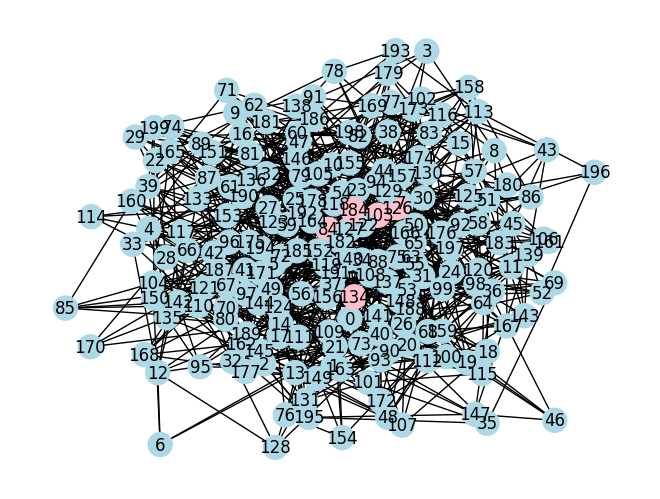

In [ ]:
# First, we create a toy graph
G = nx.gnp_random_graph(200, .05, seed=42)
while not nx.is_connected(G):
    G = nx.gnp_random_graph(200, .05, seed=42)

# For demonstration purposes, we will declare some nodes to be 'fun' nodes:
deg = nx.degree_centrality(G)
deg_sorted = sorted(deg.items(), key=lambda item: item[1],reverse=True)
fun_nodes = {n for n, _ in deg_sorted[:5]}

nx.draw(G, with_labels=True, node_color = ['pink' if n in fun_nodes else 'lightblue' for n in range(len(G.nodes))])

In [3]:
# Run the cycle space sampling with inferred p
n, p = pr.utils.estimate_er_params(G)
print(p)

# we will use a single tree for simplicity
parent, root, depth, us, vs, lcas, p_cs = pr.interface.sample_cycle_space(G, p, seed=42)

0.047336683417085426


In [4]:
# Using numpy, a lot of calculations can still be done with C-level speed

# Lengths of induced cycles
lengths = depth[us] + depth[vs] - 2 * depth[lcas] + 1

In [5]:
# Adding our own metric: number of fun nodes in the cycle

# First, we calculate the number of fun nodes on the path from root to each node
fun_depth = -1 * np.ones_like(depth)

def calc_fun_depth(node):
    if fun_depth[node] != -1:
        return
    if node == root:
        fun_depth[node] = 1 if node in fun_nodes else 0
        return
    calc_fun_depth(parent[node])
    fun_depth[node] = fun_depth[parent[node]] + (1 if node in fun_nodes else 0)

# if needed, this calculation can be done faster in Cython, numba, ...
for i in range(n):
    calc_fun_depth(i)

is_fun = np.zeros_like(fun_depth)
is_fun[list(fun_nodes)] = 1

# now, we can calulate the number of fun nodes easily:
# the lca is not counted after substracting the fun_depth of lca twice
fun_counts = fun_depth[us] + fun_depth[vs] - 2 * fun_depth[lcas] + is_fun[lcas]

In [6]:
df = pd.DataFrame({'len': lengths, 'fun': fun_counts, 'p_c': np.exp2(p_cs)})
df

,len,fun,p_c
0,12,1,3.595904e-09
1,11,1,2.510187e-08
2,5,2,1.797940e-03
3,18,2,3.602951e-14
4,19,2,4.534571e-15
...,...,...,...
738,10,0,7.192205e-08
739,23,2,4.270600e-19
740,10,0,7.192205e-08
741,5,0,1.578107e-03


<Axes: xlabel='len', ylabel='Count'>

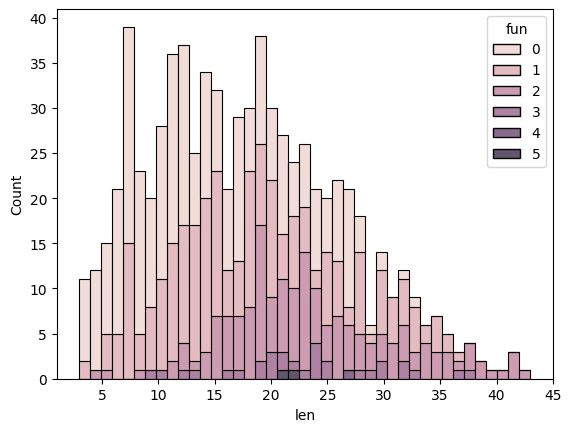

In [7]:
# how many cycles are fun, per length?
sns.histplot(data=df, x='len', hue='fun', multiple='stack', bins=len(set(lengths)))

In [8]:
df['len'].value_counts().sort_values()[-3:]

len
12    37
19    38
7     39
Name: count, dtype: int64

<Axes: xlabel='p_c', ylabel='Count'>

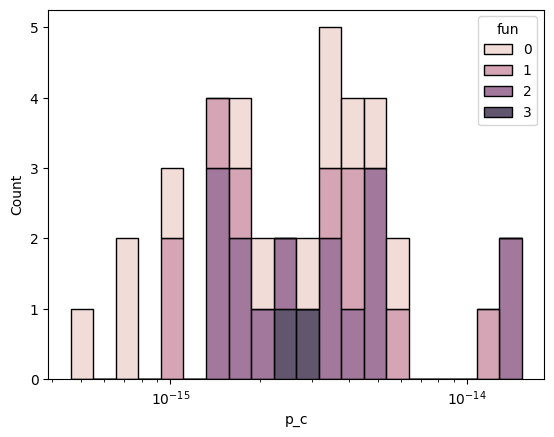

In [9]:
# length 19 is common. How fun are those cycles?
sns.histplot(data=df[df['len'] == 19], x='p_c', hue='fun', multiple='stack', log_scale=True,bins=20)

/tmp/ipykernel_752540/1434804665.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df19['weight'] = 1 / df19.p_c


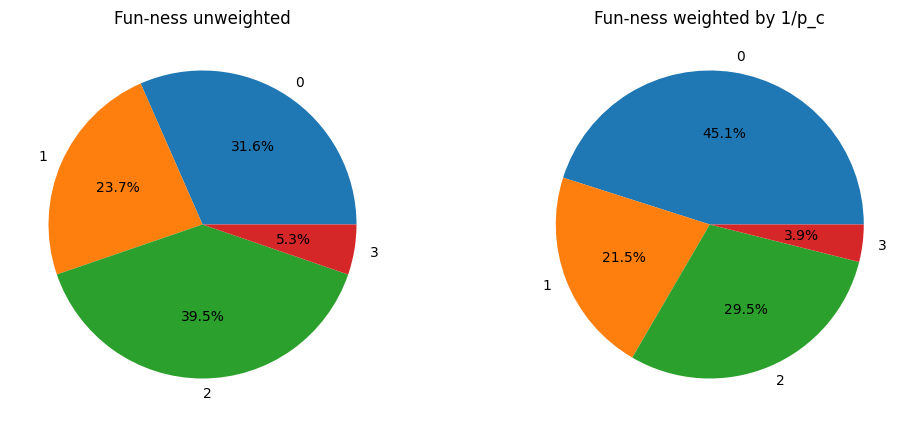

In [10]:
# This seems quite fun, but we need to remember that the sampling is skewed towards more likely cycles.
df19 = df[df['len'] == 19]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].pie(df19.fun.value_counts().sort_index(), labels=df19.fun.value_counts().sort_index().index, autopct='%1.1f%%')
axs[0].set_title('Fun-ness unweighted')

df19['weight'] = 1 / df19.p_c
weighted_counts = df19.groupby('fun')['weight'].sum().sort_index()
axs[1].pie(weighted_counts, labels=weighted_counts.index, autopct='%1.1f%%')
axs[1].set_title('Fun-ness weighted by 1/p_c')

# We see that the cycles of length 19 are less fun than we thought initially, but fun cycles are still the majority.
plt.show()